In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td

01:29:40 Pacific Daylight Time WARNING: Using canonical configuration directory 
                               at 'C:\Users\xtliang\.config\tidy3d'. Found      
                               legacy directory at '~/.tidy3d', which will be   
                               ignored. Remove it manually or run 'tidy3d config
                               migrate --delete-legacy' to clean up.            

In [14]:
def slab_hex_array(
    x0,
    y0,
    z0,
    R,
    hole_spacing_x,
    hole_spacing_y,
    n_x,
    n_y,
    height,
    hole_medium,
    slab_medium,
    reference_plane="bottom",
    sidewall_angle=0,
    axis=2,
    rotation=0,
):
    # parameters
    # ------------------------------------------------------------
    # x0: x coordinate of center of the array (um)
    # y0: y coordinate of center of the array (um)
    # z0: z coordinate of center of the array (um)
    # R: radius of the circular holes (um)
    # hole_spacing_x: distance between centers of holes in x direction (um)
    # hole_spacing_y: distance between centers of holes in y direction (um)
    # n_x: number of holes in x direction
    # n_y: number of holes in y direction
    # height: height of array
    # hole_medium: medium of the holes
    # slab_medium: medium of the slab
    # reference_plane
    # sidewall_angle: angle slant of cylinders. Add compensation for the box geometry if != 0?
    # axis
    # rotation: rotation angle of the array in radians (counter-clockwise)

    # define geometry for slab
    x_slab_length, y_slab_length = hole_spacing_x * (n_x + 0.5), hole_spacing_y * n_y

    # Choose a reference hole index to be placed exactly at (x0, y0).
    # Using integer floor indices ensures there is a specific cylinder mapped to center.
    i0 = n_x // 2
    j0 = n_y // 2

    start_x = x0 - (i0 + (j0 % 2) * 0.5) * hole_spacing_x
    start_y = y0 - j0 * hole_spacing_y

    box = td.Box(center=(x0, y0, z0), size=(x_slab_length, y_slab_length, height))

    structures = [td.Structure(geometry=box, medium=slab_medium)]

    cylinders = []

    # precompute rotation
    cos_theta = np.cos(rotation)
    sin_theta = np.sin(rotation)

    for i in range(0, n_x):
        for j in range(0, n_y):
            cx = start_x + (i + (j % 2) * 0.5) * hole_spacing_x
            cy = start_y + j * hole_spacing_y
            dx = cx - x0
            dy = cy - y0
            rx = x0 + cos_theta * dx - sin_theta * dy
            ry = y0 + sin_theta * dx + cos_theta * dy

            c = td.Cylinder(
                axis=axis,
                sidewall_angle=sidewall_angle,
                reference_plane=reference_plane,
                radius=R,
                center=(rx, ry, z0),
                length=height,
            )
            cylinders.append(c)

    cylinders_structure = td.Structure(
        geometry=td.GeometryGroup(geometries=cylinders), medium=hole_medium
    )

    structures.append(cylinders_structure)

    return structures

In [15]:
# para
theta = 9.43 * np.pi / 180
am = 3.04

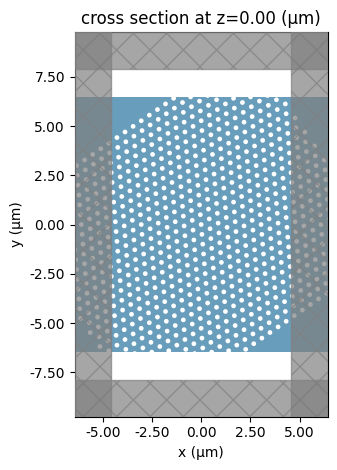

In [19]:
s = slab_hex_array(
    0,
    0,
    0,
    0.12,
    0.5,
    0.5*np.sqrt(3)/2,
    30,
    30,
    0.2,
    td.Medium(permittivity=1**2),
    td.Medium(permittivity=3.4**2),
    rotation=np.pi/6 + theta/2
)

sim = td.Simulation(
    # size=[am, am*np.sqrt(3), 10],
    size = [am*3, am*np.sqrt(3)*3, 10],
    grid_spec=td.GridSpec.auto(wavelength=1.55),
    structures=s,
    run_time=1,
)

sim.plot(z=0)
plt.show()

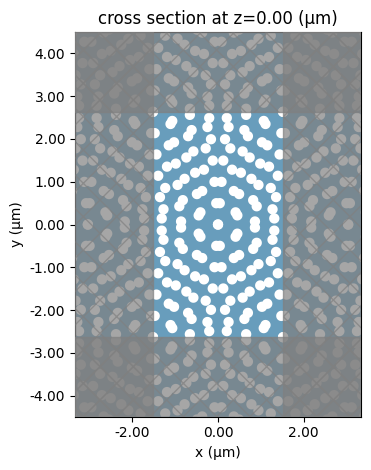

In [21]:
# =========================================================
# Moire pattern: two rotations of the hole array
# =========================================================
# Create first array with rotation = np.pi/6 + theta/2
s1 = slab_hex_array(
    0, 0, 0, 0.12,
    0.5, 0.5*np.sqrt(3)/2,
    30, 30, 0.2,
    td.Medium(permittivity=1**2),
    td.Medium(permittivity=3.4**2),
    rotation=np.pi/6 + theta/2
)

# Create second array with rotation = np.pi/6 - theta/2
s2 = slab_hex_array(
    0, 0, 0, 0.12,
    0.5, 0.5*np.sqrt(3)/2,
    30, 30, 0.2,
    td.Medium(permittivity=1**2),
    td.Medium(permittivity=3.4**2),
    rotation=np.pi/6 - theta/2
)

# Combine structures:
# s1[0] = slab medium (base plate)
# s1[1] = first set of cylinders (air holes, rotation 1)
# s2[1] = second set of cylinders (air holes, rotation 2)
# Medium order matters: slab first, then both sets of holes
moire_structures = [s1[0], s1[1], s2[1]]

sim_moire = td.Simulation(
    # size=[am*3, am*np.sqrt(3)*3, 10],
    size=[am, am*np.sqrt(3), 10],
    grid_spec=td.GridSpec.auto(wavelength=1.55),
    structures=moire_structures,
    run_time=1,
)

sim_moire.plot(z=0)
plt.show()